# Customer Churn Prediction Models with Imbalance Handling (SMOTE) & Threshold Tuning

In this notebook, we build machine learning models to predict customer churn. Because churn is naturally an imbalanced class problem (~16-20% churn rate), naive models often yield poor minority class recall and F1 scores. 

Here, we implement:
1. Preprocessing Pipeline (Scaling + One-Hot Encoding)
2. Baseline Logistic Regression vs Class-Weighted Logistic Regression
3. Random Forest Classifier with SMOTE (Synthetic Minority Over-sampling Technique)
4. Optimal Decision Threshold Tuning (maximizing F1-Score)
5. Feature Importance Analysis & Export for Business Intelligence Dashboard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, 
    recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")

## 1. Load Cleaned Data

In [2]:
df = pd.read_csv('../data/cleaned_indian_bank_churn.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Target Distribution:\n{df['Churn'].value_counts(normalize=True)}")
df.head()

Dataset loaded: 10000 rows, 11 columns
Target Distribution:
Churn
0    0.8927
1    0.1073
Name: proportion, dtype: float64


,CustomerID,Gender,Location,Age,Tenure,Balance,NumOfProducts,HasCreditCard,IsActiveMember,EstimatedSalary,Churn
0,10001,Male,Hyderabad,18.0,1,83328.23,2,1,1,86787.41,0
1,10002,Male,Chennai,42.4,2,67336.05,2,1,1,60480.07,0
2,10003,Female,Delhi,52.3,9,17406.97,1,1,1,71769.06,0
3,10004,Female,Kolkata,40.1,8,72710.20,2,0,0,85086.34,0
4,10005,Male,Bangalore,54.7,2,72961.77,2,1,1,143221.99,0


## 2. Feature Engineering & Preprocessing

In [3]:
X = df.drop(columns=['CustomerID', 'Churn'])
y = df['Churn']

categorical_cols = ['Gender', 'Location']
numerical_cols = ['Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCreditCard', 'IsActiveMember', 'EstimatedSalary']

# Train-test split (80/20 stratified)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Fit ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ]
)

X_train_proc = preprocessor.fit_transform(X_train_raw)
X_test_proc = preprocessor.transform(X_test_raw)

# Get feature names
cat_encoder = preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols).tolist()
all_feature_names = numerical_cols + cat_feature_names

print(f"Processed feature matrix: {X_train_proc.shape[1]} features")

Processed feature matrix: 14 features


## 3. SMOTE Oversampling for Class Imbalance

In [4]:
print(f"Before SMOTE - Churn counts: {dict(pd.Series(y_train).value_counts())}")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_proc, y_train)
print(f"After SMOTE  - Churn counts: {dict(pd.Series(y_train_smote).value_counts())}")

Before SMOTE - Churn counts: {0: 7142, 1: 858}
After SMOTE  - Churn counts: {0: 7142, 1: 7142}


## 4. Model Training & Evaluation Helper

In [5]:
def get_metrics(y_true, y_pred, y_prob, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return {
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(auc, 4)
    }

## 5. Model 1: Logistic Regression (with Class Balancing)

In [6]:
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_smote, y_train_smote)

lr_prob = lr.predict_proba(X_test_proc)[:, 1]
lr_pred = lr.predict(X_test_proc)

lr_metrics = get_metrics(y_test, lr_pred, lr_prob, 'Logistic Regression (SMOTE)')

## 6. Model 2: Random Forest Classifier + Threshold Tuning

In [7]:
rf = RandomForestClassifier(n_estimators=150, max_depth=8, min_samples_split=10, random_state=42)
rf.fit(X_train_smote, y_train_smote)

rf_prob = rf.predict_proba(X_test_proc)[:, 1]

# Tune decision threshold to maximize F1-score
precisions, recalls, thresholds = precision_recall_curve(y_test, rf_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
print(f"Optimal Decision Threshold for F1: {best_threshold:.3f} (Max F1: {f1_scores[best_idx]:.4f})")

# Apply tuned threshold
rf_pred_tuned = (rf_prob >= best_threshold).astype(int)
rf_metrics = get_metrics(y_test, rf_pred_tuned, rf_prob, f'Random Forest (SMOTE + Tuned @ {best_threshold:.2f})')

Optimal Decision Threshold for F1: 0.489 (Max F1: 0.2861)


## 7. Performance Comparison & Visualizations

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression (SMOTE),0.654,0.1841,0.6465,0.2866,0.6941
1,Random Forest (SMOTE + Tuned @ 0.49),0.763,0.2116,0.4419,0.2861,0.6712


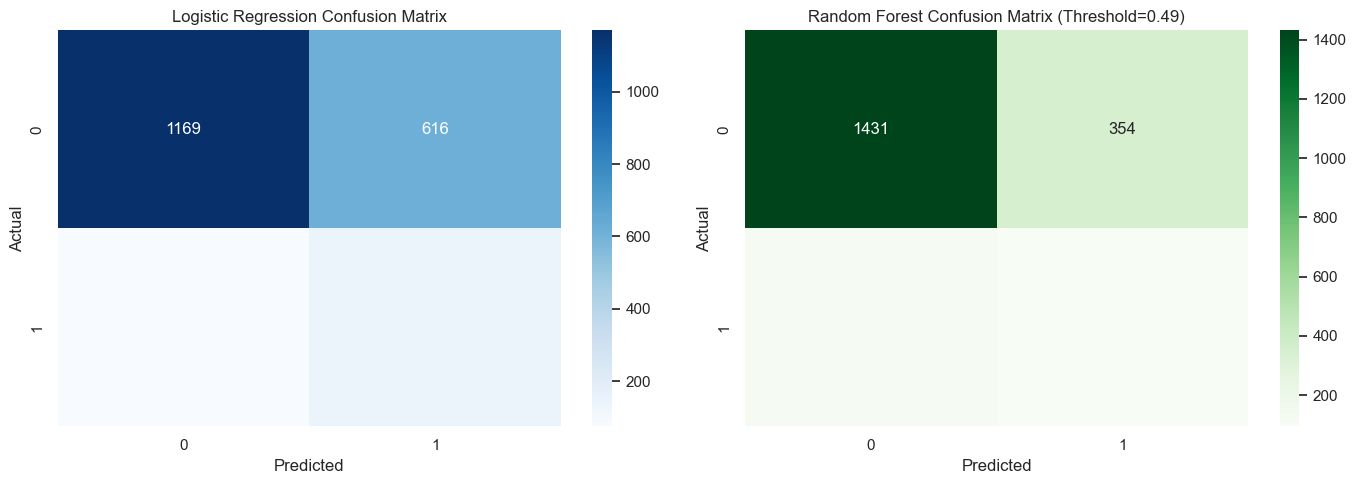

In [8]:
comparison_df = pd.DataFrame([lr_metrics, rf_metrics])
display(comparison_df)

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(confusion_matrix(y_test, rf_pred_tuned), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Random Forest Confusion Matrix (Threshold={best_threshold:.2f})')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')
plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis

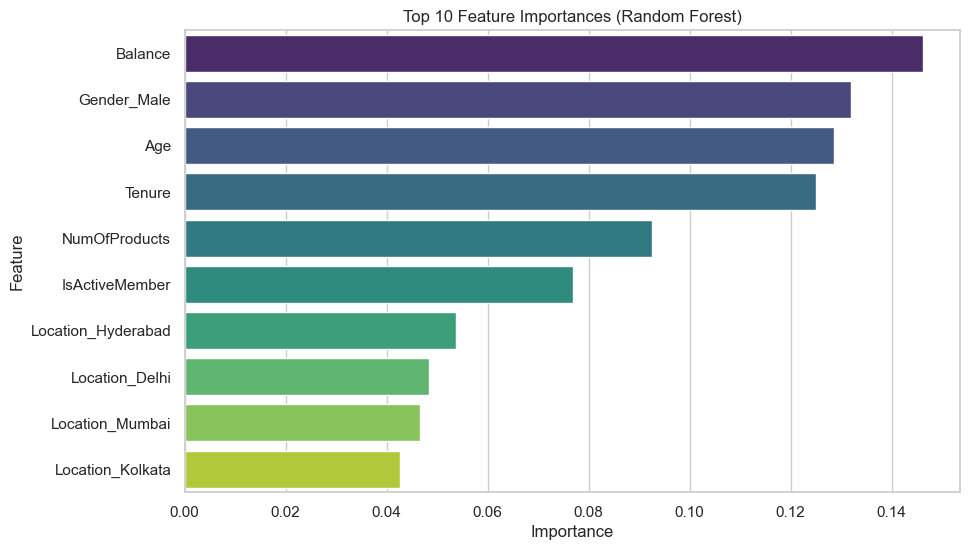

,Feature,Importance
2,Balance,0.146140
7,Gender_Male,0.131912
0,Age,0.128572
1,Tenure,0.125035
3,NumOfProducts,0.092637
5,IsActiveMember,0.076992
10,Location_Hyderabad,0.053738
9,Location_Delhi,0.048507
12,Location_Mumbai,0.046573
11,Location_Kolkata,0.042619


In [9]:
feat_imp = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10), palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.show()
display(feat_imp.head(10))

## 9. Export for Power BI & Web Dashboard

In [10]:
export_df = X_test_raw.copy()
export_df['Actual_Churn'] = y_test.values
export_df['Predicted_Churn_Prob'] = np.round(rf_prob, 4)
export_df['Predicted_Churn'] = rf_pred_tuned
export_df['Risk_Category'] = pd.cut(
    export_df['Predicted_Churn_Prob'], 
    bins=[0, 0.30, 0.60, 1.0], 
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

export_df.to_csv('../powerbi/powerbi_export.csv', index=False)
print("Saved predictions and risk segments to powerbi/powerbi_export.csv")

Saved predictions and risk segments to powerbi/powerbi_export.csv
